# IMPORTACIÓN DE BIBLIOTECAS Y LIBRERÍAS 

In [1]:
import pandas as pd
import missingno as msno
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import skew, kurtosis, norm
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import accuracy_score


# 1 INGESTIÓN O CARGA DE DATOS

In [2]:
df_original = pd.read_csv(r"https://raw.githubusercontent.com/4GeeksAcademy/k-nearest-neighbors-project-tutorial/refs/heads/main/winequality-red.csv" , sep=";")

print(f"TAMAÑO DEL DATASET: {df_original.shape[0]} filas x {df_original.shape[1]} columnas")

TAMAÑO DEL DATASET: 1599 filas x 12 columnas


# 2 INSPECCIÓN INICIAL

## 2.1 VISUALIZACIÓN DE TODAS LAS COLUMNAS 

In [3]:
pd.set_option('display.max_columns', None)
# Esto sirve para que me muestre todas las columnas cuando un DataSet es muy ancho o con muchas columnas 
# Con el (None) le digo que me muestre todas las columnas sin limitación
df_original.head(3)

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5


## 2.2 INFORMACIÓN DEL DATASET 

In [4]:
# Información general del dataset
print("INFORMACIÓN GENERAL:")
print("="*80)
df_original.info()

print("\n" + "="*80)

# Lista de columnas
print("COLUMNAS DEL DATASET:\n")
print(df_original.columns.tolist())

INFORMACIÓN GENERAL:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1599 entries, 0 to 1598
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1599 non-null   float64
 1   volatile acidity      1599 non-null   float64
 2   citric acid           1599 non-null   float64
 3   residual sugar        1599 non-null   float64
 4   chlorides             1599 non-null   float64
 5   free sulfur dioxide   1599 non-null   float64
 6   total sulfur dioxide  1599 non-null   float64
 7   density               1599 non-null   float64
 8   pH                    1599 non-null   float64
 9   sulphates             1599 non-null   float64
 10  alcohol               1599 non-null   float64
 11  quality               1599 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 150.0 KB

COLUMNAS DEL DATASET:

['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar', 'chlorides

## 2.3 CLASIFICACIÓN DE COLUMNAS DEL DATASET PARA DETECTAR NÚMERICAS, CATEGÓRICAS, BOOLEANAS Y DATETIME

In [5]:
numerical_cols = df_original.select_dtypes(include=['int64', 'float64']).columns.tolist()
print("\n" + "="*80)
print("COLUMNAS NUMÉRICAS:\n")
print(numerical_cols)
print(f"Cantidad de Columnas Numéricas: {len(numerical_cols)}")

categorical_cols = df_original.select_dtypes(include=['object', 'category']).columns.tolist()
print("\n" + "="*80)
print("COLUMNAS CATEGÓRICAS:\n")
print(categorical_cols)
print(f"Cantidad de Columnas Categóricas: {len(categorical_cols)}")

boolean_cols = df_original.select_dtypes(include=['bool']).columns.tolist()
print("\n" + "="*80)    
print("COLUMNAS BOOLEANAS:\n")
print(boolean_cols)
print(f"Cantidad de Columnas Booleanas: {len(boolean_cols)}")

datetime_cols = df_original.select_dtypes(include=['datetime64']).columns.tolist()
print("\n" + "="*80)    
print("COLUMNAS DE FECHA Y HORA:\n")
print(datetime_cols)
print(f"Cantidad de Columnas de Fecha y Hora: {len(datetime_cols)}")


COLUMNAS NUMÉRICAS:

['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar', 'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density', 'pH', 'sulphates', 'alcohol', 'quality']
Cantidad de Columnas Numéricas: 12

COLUMNAS CATEGÓRICAS:

[]
Cantidad de Columnas Categóricas: 0

COLUMNAS BOOLEANAS:

[]
Cantidad de Columnas Booleanas: 0

COLUMNAS DE FECHA Y HORA:

[]
Cantidad de Columnas de Fecha y Hora: 0


## 2.4 DESCRIPCIÓN GENERAL DEL DATASET

In [6]:
df_original.describe(include='all').T # Include all sirve para que me muestre todas las estadísticas de todas las variables, incluyendo las categóricas

,count,mean,std,min,25%,50%,75%,max
fixed acidity,1599.0,8.319637,1.741096,4.60000,7.1000,7.90000,9.200000,15.90000
volatile acidity,1599.0,0.527821,0.179060,0.12000,0.3900,0.52000,0.640000,1.58000
citric acid,1599.0,0.270976,0.194801,0.00000,0.0900,0.26000,0.420000,1.00000
residual sugar,1599.0,2.538806,1.409928,0.90000,1.9000,2.20000,2.600000,15.50000
chlorides,1599.0,0.087467,0.047065,0.01200,0.0700,0.07900,0.090000,0.61100
free sulfur dioxide,1599.0,15.874922,10.460157,1.00000,7.0000,14.00000,21.000000,72.00000
total sulfur dioxide,1599.0,46.467792,32.895324,6.00000,22.0000,38.00000,62.000000,289.00000
density,1599.0,0.996747,0.001887,0.99007,0.9956,0.99675,0.997835,1.00369
pH,1599.0,3.311113,0.154386,2.74000,3.2100,3.31000,3.400000,4.01000
sulphates,1599.0,0.658149,0.169507,0.33000,0.5500,0.62000,0.730000,2.00000


## 2.5 ANÁLISIS DE DISTRIBUCCIÓN PARA COLUMNAS NÚMERICAS

In [7]:
numerical_cols = df_original.select_dtypes(include=['int64', 'float64']).columns

# Crear DataFrame con estadísticas de distribución
dist_stats = pd.DataFrame({
    'Variable': numerical_cols,
    'Media': [df_original[col].mean() for col in numerical_cols],
    'Mediana': [df_original[col].median() for col in numerical_cols],
    'Desv_Std': [df_original[col].std() for col in numerical_cols],
    'Skewness': [skew(df_original[col].dropna()) for col in numerical_cols],
    'Kurtosis': [kurtosis(df_original[col].dropna()) for col in numerical_cols]
})

# Determinar tipo de distribución
def clasificar_distribucion(skew_val, kurt_val):
    # Clasificar por skewness 
    # ¿Hacia dónde se inclina?
    if abs(skew_val) < 0.5:
        tipo_skew = "Simétrica"
    elif skew_val > 0.5:
        tipo_skew = "Asimétrica +"
    else:
        tipo_skew = "Asimétrica -"
    
    # Clasificar por kurtosis
    # ¿Qué tan puntiaguda es? 
    # La kurtosis mayor a 1 es la que me indica cuantos outliers tengo 
    # mientras mas se aleja de 1 mayor atención debo prestar a esa variable
    if kurt_val > 1:
        tipo_kurt = "Leptocúrtica"
    elif kurt_val < -1:
        tipo_kurt = "Platicúrtica"
    else:
        tipo_kurt = "Mesocúrtica"
    
    return f"{tipo_skew} | {tipo_kurt}"

dist_stats['Tipo_Distribución'] = dist_stats.apply(
    lambda row: clasificar_distribucion(row['Skewness'], row['Kurtosis']), axis=1
)

# Redondear valores para mejor visualización
dist_stats = dist_stats.round(3)

print("=" * 100)
print("ANÁLISIS DE DISTRIBUCIÓN POR VARIABLE")
print("=" * 100)
print("\nGuía de Interpretación:")
print("  • Skewness: |valor| < 0.5 (Simétrica), > 0.5 (Asimétrica +), < -0.5 (Asimétrica -)")
print("  • Kurtosis: > 1 (Leptocúrtica/Puntiaguda), < -1 (Platicúrtica/Achatada), entre -1 y 1 (Mesocúrtica/Normal)")
print("\n")

dist_stats

ANÁLISIS DE DISTRIBUCIÓN POR VARIABLE

Guía de Interpretación:
  • Skewness: |valor| < 0.5 (Simétrica), > 0.5 (Asimétrica +), < -0.5 (Asimétrica -)
  • Kurtosis: > 1 (Leptocúrtica/Puntiaguda), < -1 (Platicúrtica/Achatada), entre -1 y 1 (Mesocúrtica/Normal)




,Variable,Media,Mediana,Desv_Std,Skewness,Kurtosis,Tipo_Distribución
0,fixed acidity,8.320,7.900,1.741,0.982,1.125,Asimétrica + | Leptocúrtica
1,volatile acidity,0.528,0.520,0.179,0.671,1.218,Asimétrica + | Leptocúrtica
2,citric acid,0.271,0.260,0.195,0.318,-0.790,Simétrica | Mesocúrtica
3,residual sugar,2.539,2.200,1.410,4.536,28.524,Asimétrica + | Leptocúrtica
4,chlorides,0.087,0.079,0.047,5.675,41.582,Asimétrica + | Leptocúrtica
5,free sulfur dioxide,15.875,14.000,10.460,1.249,2.013,Asimétrica + | Leptocúrtica
6,total sulfur dioxide,46.468,38.000,32.895,1.514,3.794,Asimétrica + | Leptocúrtica
7,density,0.997,0.997,0.002,0.071,0.927,Simétrica | Mesocúrtica
8,pH,3.311,3.310,0.154,0.194,0.801,Simétrica | Mesocúrtica
9,sulphates,0.658,0.620,0.170,2.426,11.680,Asimétrica + | Leptocúrtica


## 2.6 HISTOGRAMA DE DISTRIBUCCIÓN PARA COLUMNAS NÚMERICAS

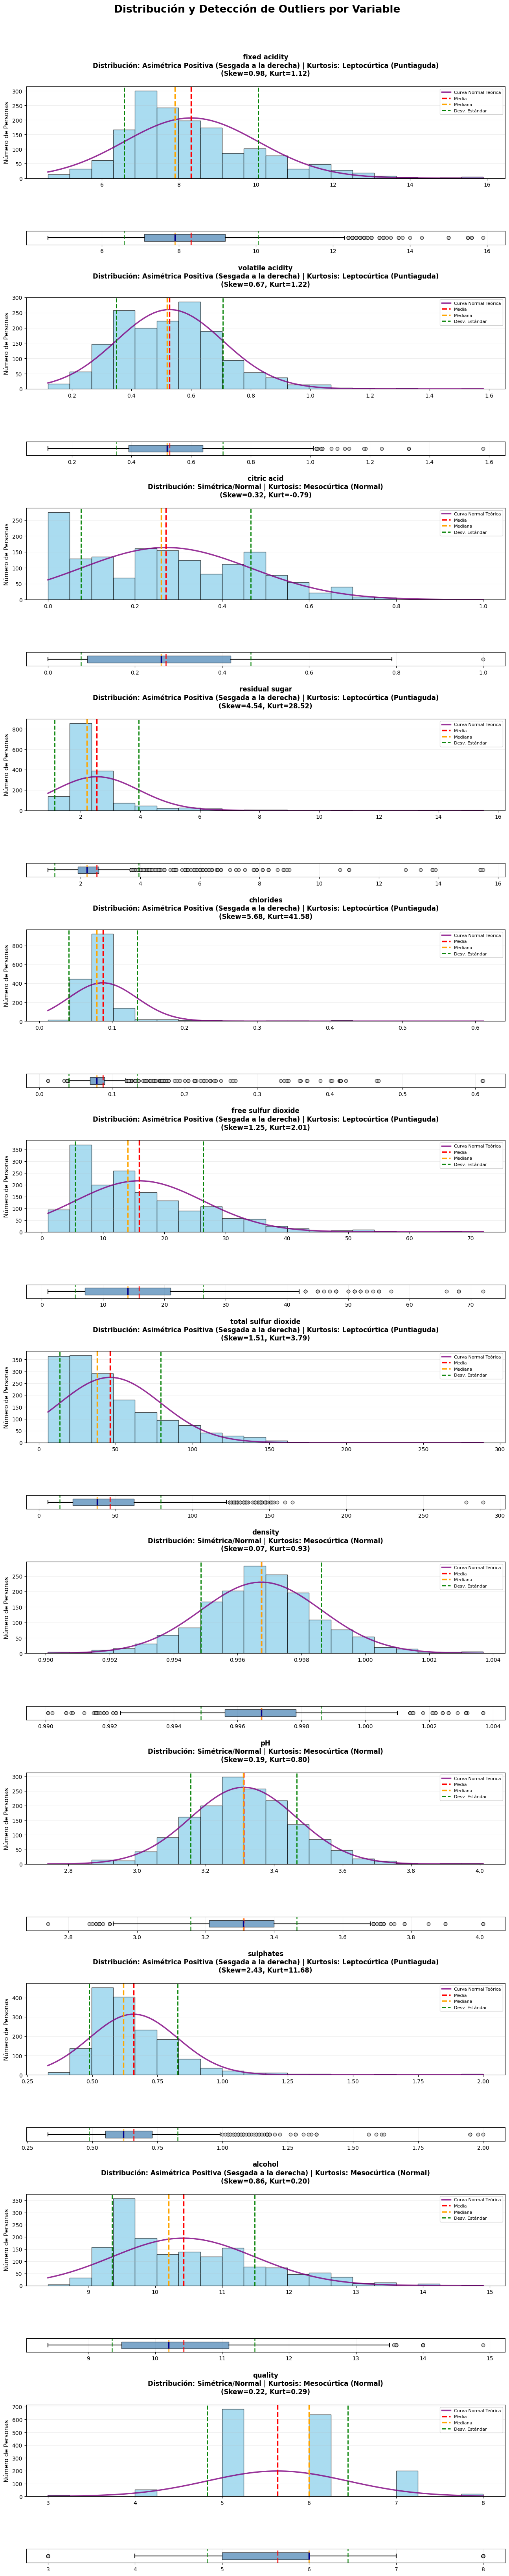

In [8]:
# Histogramas con estadísticas y boxplots
# Calcular el número de variables numéricas dinámicamente
num_vars = len(numerical_cols)
fig = plt.figure(figsize=(14, num_vars * 5.5))
gs = fig.add_gridspec(num_vars * 2, 1, hspace=1, height_ratios=[10, 1.5] * num_vars)

row = 0
for idx, col in enumerate(numerical_cols):
    data = df_original[col].dropna()
    
    # Calcular estadísticas
    mean_val = data.mean()
    median_val = data.median()
    std_val = data.std()
    skewness = skew(data) 
    kurt = kurtosis(data) 
    
    # Determinar tipo de distribución por skewness
    if abs(skewness) < 0.5:
        dist_type = "Simétrica/Normal"
    elif skewness > 0.5:
        dist_type = "Asimétrica Positiva (Sesgada a la derecha)"
    else:
        dist_type = "Asimétrica Negativa (Sesgada a la izquierda)"
    
    # Determinar tipo de kurtosis
    if kurt > 1:
        kurt_type = "Leptocúrtica (Puntiaguda)"
    elif kurt < -1:
        kurt_type = "Platicúrtica (Achatada)"
    else:
        kurt_type = "Mesocúrtica (Normal)"
    
    # Histograma (fila superior) - CONTEO DE PERSONAS
    ax_hist = fig.add_subplot(gs[row, 0])
    n, bins, patches = ax_hist.hist(data, bins=20, edgecolor='black', alpha=0.7, 
                                      color='skyblue', density=False)
    
    # Superponer curva normal de referencia - ESCALADA AL CONTEO
    x = np.linspace(data.min(), data.max(), 100)
    # Escalar la curva normal para que se ajuste al histograma de conteos
    bin_width = bins[1] - bins[0]  # Ancho de cada barra
    scale_factor = len(data) * bin_width  # Factor de escala
    ax_hist.plot(x, norm.pdf(x, mean_val, std_val) * scale_factor, 
                 color='purple', linewidth=2.5, linestyle='-', 
                 label='Curva Normal Teórica', alpha=0.8)
    
    # Líneas verticales de estadísticas
    ax_hist.axvline(mean_val, color='red', linestyle='--', linewidth=2.5, 
                    label=f'Media')
    ax_hist.axvline(median_val, color='orange', linestyle='--', linewidth=2.5, 
                    label=f'Mediana')
    ax_hist.axvline(mean_val + std_val, color='green', linestyle='--', linewidth=2, 
                    label=f'Desv. Estándar')
    ax_hist.axvline(mean_val - std_val, color='green', linestyle='--', linewidth=2)
    
    # Título con tipo de distribución, skewness y kurtosis
    ax_hist.set_title(f'{col}\nDistribución: {dist_type} | Kurtosis: {kurt_type}\n(Skew={skewness:.2f}, Kurt={kurt:.2f})', 
                      fontsize=12, fontweight='bold', pad=20)
    ax_hist.set_ylabel('Número de Personas', fontsize=11)
    ax_hist.legend(fontsize=8, loc='upper right', framealpha=0.9)
    ax_hist.grid(True, alpha=0.2, axis='y')
    
    # Boxplot horizontal (fila inferior)
    ax_box = fig.add_subplot(gs[row + 1, 0])
    bp = ax_box.boxplot(data, vert=False, patch_artist=True, widths=0.5,
                         boxprops=dict(facecolor='steelblue', alpha=0.7, edgecolor='black'),
                         medianprops=dict(color='darkblue', linewidth=2.5),
                         whiskerprops=dict(color='black', linewidth=1.5),
                         capprops=dict(color='black', linewidth=1.5),
                         flierprops=dict(marker='o', markerfacecolor='lightgray', 
                                       markeredgecolor='black', markersize=6, alpha=0.7))
    
    # Proyectar líneas de estadísticas en el boxplot
    ax_box.axvline(mean_val, color='red', linestyle='--', linewidth=2.5, alpha=0.7)
    ax_box.axvline(median_val, color='orange', linestyle='--', linewidth=2.5, alpha=0.7)
    ax_box.axvline(mean_val + std_val, color='green', linestyle='--', linewidth=2, alpha=0.7)
    ax_box.axvline(mean_val - std_val, color='green', linestyle='--', linewidth=2, alpha=0.7)
    
    ax_box.set_xlim(ax_hist.get_xlim())
    ax_box.grid(True, alpha=0.2, axis='x')
    ax_box.tick_params(axis='y', which='both', left=False, labelleft=False)
    ax_box.set_xlabel('')
    
    row += 2

plt.suptitle('Distribución y Detección de Outliers por Variable', 
             fontsize=19, fontweight='bold', y=1.002)
plt.subplots_adjust(top=0.97, bottom=0.015, left=0.08, right=0.95)
plt.show()

# 3 CRIBADO DE VARIABLES 

## 3.1 DFINICIÓN DE OBJETIVO DE ESTUDIO 

Entrena un modelo de K-Vecinos más Cercanos (KNN) para predecir la calidad de un vino tinto a partir de sus características químicas.

## 3.2 CREACIÓN DE DATASET PARA TRABAJAR

In [9]:
df = df_original.copy()

## 3.3 VERIFICACIÓN DE VALORES ÚNICOS POR CADA COLUMNA Y BÚSQUEDA DE VALORES FALTANTES ENMASCARADOS

In [10]:
# Verificar columnas con valores únicos igual a 1
columnas_un_valor = df.nunique()[df.nunique() == 1]

if len(columnas_un_valor) > 0:
    print("="*50)
    print("COLUMNAS CON VALORES ÚNICOS = 1")
    print("="*50)
    print("\n Nombres de las Columnas:")
    print(columnas_un_valor.index.tolist())
    print(f"\n Total de Columnas con un Solo Valor: {len(columnas_un_valor)}")
else:
    print("="*50)
    print("No hay Columnas con Valores Únicos igual a 1")
    print("="*50)

# Análisis de valores únicos por columna
for columna in df.columns: # → Recorre todas las columnas 
    print(f"\n{'='*25}")
    print(f"COLUMNA: {columna}")
    print(f"{'='*25}")
    print(df[columna].value_counts()) # Muestra cada valor único y cuántas veces aparece, ordenado de mayor a menor frecuencia
    print(f"\nTotal de Valores Únicos: {df[columna].nunique()}") # → Cuenta cuántos valores diferentes hay en total  

No hay Columnas con Valores Únicos igual a 1

COLUMNA: fixed acidity
fixed acidity
7.2     67
7.1     57
7.8     53
7.5     52
7.0     50
        ..
14.3     1
12.1     1
15.9     1
4.9      1
5.5      1
Name: count, Length: 96, dtype: int64

Total de Valores Únicos: 96

COLUMNA: volatile acidity
volatile acidity
0.600    47
0.500    46
0.430    43
0.590    39
0.580    38
         ..
1.005     1
0.955     1
1.580     1
1.180     1
0.895     1
Name: count, Length: 143, dtype: int64

Total de Valores Únicos: 143

COLUMNA: citric acid
citric acid
0.00    132
0.49     68
0.24     51
0.02     50
0.26     38
       ... 
0.79      1
0.71      1
0.72      1
0.75      1
0.78      1
Name: count, Length: 80, dtype: int64

Total de Valores Únicos: 80

COLUMNA: residual sugar
residual sugar
2.00     156
2.20     131
1.80     129
2.10     128
1.90     117
        ... 
12.90      1
5.40       1
3.75       1
5.70       1
13.90      1
Name: count, Length: 91, dtype: int64

Total de Valores Únicos: 91



## 3.4 VERIFICACIÓN DE DATOS FALTANTES EN COLUMNAS

In [11]:
df.isnull().sum()

fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
dtype: int64

## 3.5 VERIFICACIÓN DE DATOS FALTANTES EN FILAS > 40%

In [12]:
df_filas_faltantes = (df.T.isnull().sum()* 100 / len(df)).round(2)
if df_filas_faltantes[df_filas_faltantes > 0.40].any():
    print(df_filas_faltantes[df_filas_faltantes > 0.40])
else:
    print("No hay Filas con Valores Faltantes > 40 % en el DataSet")

No hay Filas con Valores Faltantes > 40 % en el DataSet


## 3.6 GRÁFICA DE VALORES FALTANTES 

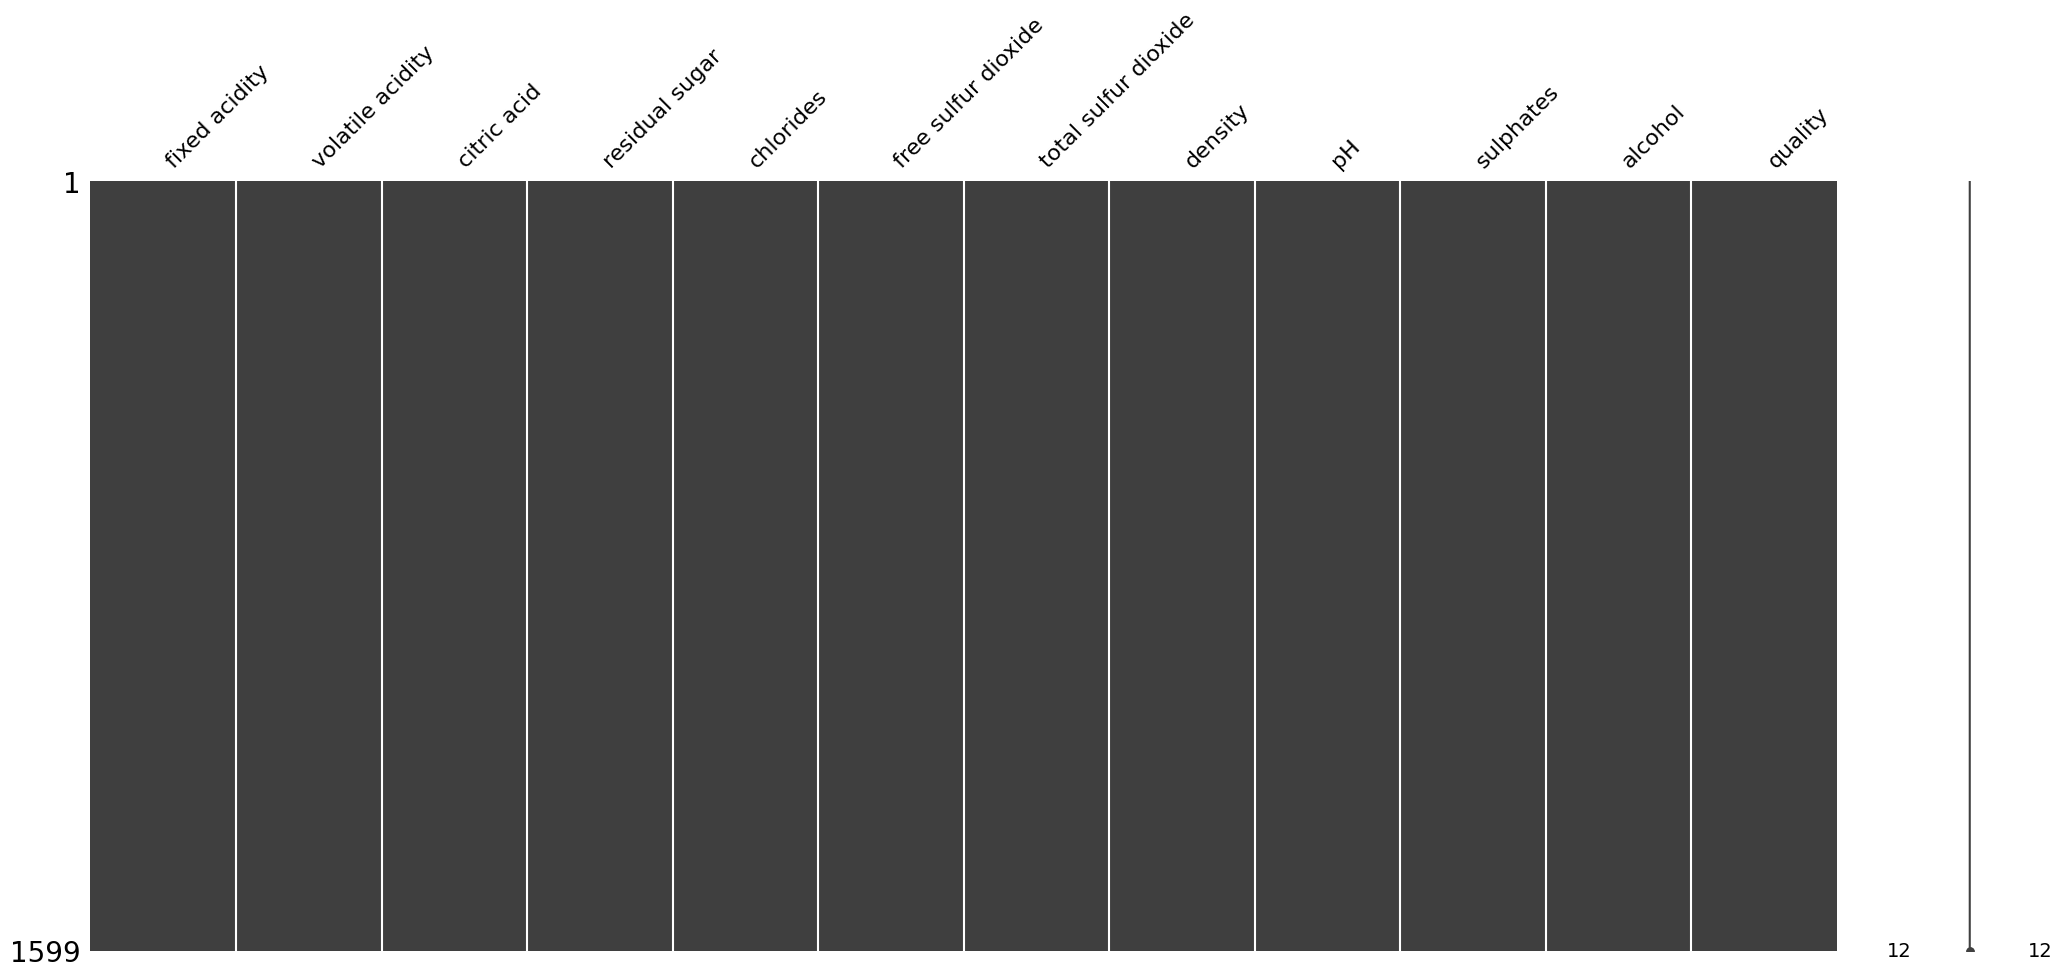

In [13]:
msno.matrix(df)
plt.show()

## 3.7 COMPROBACIÓN DE DATOS DUPLICADOS EN FILAS

In [14]:
filas_duplicadas = df[df.duplicated(keep=False)] # keep=False muestra TODAS las ocurrencias (incluyendo la original)

if len(filas_duplicadas) > 0:
    print(f"Se Encontraron {len(filas_duplicadas)} Filas Duplicadas:")
    print(f"Esto Representa {len(filas_duplicadas)/len(df)*100:.2f}% del DataSet\n")
    print(filas_duplicadas)
else:
    print("No hay Filas Duplicadas en el DataSet")

Se Encontraron 460 Filas Duplicadas:
Esto Representa 28.77% del DataSet

      fixed acidity  volatile acidity  citric acid  residual sugar  chlorides  \
0               7.4             0.700         0.00             1.9      0.076   
4               7.4             0.700         0.00             1.9      0.076   
9               7.5             0.500         0.36             6.1      0.071   
11              7.5             0.500         0.36             6.1      0.071   
22              7.9             0.430         0.21             1.6      0.106   
...             ...               ...          ...             ...        ...   
1567            7.2             0.695         0.13             2.0      0.076   
1579            6.2             0.560         0.09             1.7      0.053   
1581            6.2             0.560         0.09             1.7      0.053   
1592            6.3             0.510         0.13             2.3      0.076   
1596            6.3             0.51

## 3.8 ELIMINAR FILAS DUPLICADAS 

In [15]:
df.drop_duplicates(keep='first', inplace=True)
df.duplicated().sum()

np.int64(0)

## 3.9 COMPROBACIÓN DE DATOS DUPLICADOS EN COLUMNAS CON LA TRANSPUESTA

In [16]:
columnas_duplicadas = df.T.duplicated(keep=False).sum()

if columnas_duplicadas > 0:
    print(f"\nSe Encontraron {columnas_duplicadas} Columnas Duplicadas")
    print("\nNombres de las Columnas Duplicadas:")
    print(df.T[df.T.duplicated(keep=False)].index)
else:
    print("\nNo hay Columnas Duplicadas en el DataSet")


No hay Columnas Duplicadas en el DataSet


## 3.10 DETECCIÓN DE OUTLIERS 

In [17]:
# Lista de columnas que quiero analizar
columnas = [col for col in df.columns]

# Para guardar los resultados
resultados = []

# Analizar cada columna una por una
for columna in columnas:
    
    # Obtener los datos de la columna
    datos = df[columna]
    
    # Calcular Q1 (25%), Q3 (75%) y IQR
    Q1 = datos.quantile(0.25)  # 25% de los datos
    Q3 = datos.quantile(0.75)  # 75% de los datos
    IQR = Q3 - Q1              # Diferencia entre Q3 y Q1
    
    # Calcular límites
    limite_bajo = Q1 - 1.5 * IQR
    limite_alto = Q3 + 1.5 * IQR
    
    # Contar outliers
    outliers_bajos = (datos < limite_bajo).sum()
    outliers_altos = (datos > limite_alto).sum()
    total_outliers = outliers_bajos + outliers_altos
    
    # Calcular porcentaje
    porcentaje = (total_outliers / len(datos)) * 100
    
    # Guardar en la lista
    resultados.append({
        'Columna': columna,
        'Q1': Q1,
        'Q3': Q3,
        'IQR': IQR,
        'Limite_Bajo': limite_bajo,
        'Limite_Alto': limite_alto,
        'Total_Outliers': total_outliers,
        'Porcentaje': round(porcentaje, 2)
    })

# Convertir a DataFrame para verlo bonito
df_outliers = pd.DataFrame(resultados)

# Mostrar resultados
print("="*80)
print("ANÁLISIS DE OUTLIERS")
print("="*80)
print(df_outliers)
print("="*80)

# Explicar qué significa
print("\nINTERPRETACIÓN:")
for i in range(len(df_outliers)):
    col = df_outliers.loc[i, 'Columna']
    limite_bajo = df_outliers.loc[i, 'Limite_Bajo']
    limite_alto = df_outliers.loc[i, 'Limite_Alto']
    total = df_outliers.loc[i, 'Total_Outliers']
    pct = df_outliers.loc[i, 'Porcentaje']
    
    print(f"\n{col}:")
    print(f"  - Valores Normales: Entre {limite_bajo:.1f} y {limite_alto:.1f}")
    print(f"  - Outliers Encontrados: {total} ({pct}%)")
    
    if pct < 5:
        print(f"Pocos Outliers, Está Bien")
    elif pct < 10:
        print(f"Algunos Outliers")
    else:
        print(f"Muchos Outliers")
        
print("="*80)
print("\nSUMA DEL TOTAL DE OUTLIERS EN PORCENTAJE:")
print(df_outliers['Porcentaje'].sum())

ANÁLISIS DE OUTLIERS
                 Columna       Q1        Q3       IQR  Limite_Bajo  \
0          fixed acidity   7.1000   9.20000   2.10000      3.95000   
1       volatile acidity   0.3900   0.64000   0.25000      0.01500   
2            citric acid   0.0900   0.43000   0.34000     -0.42000   
3         residual sugar   1.9000   2.60000   0.70000      0.85000   
4              chlorides   0.0700   0.09100   0.02100      0.03850   
5    free sulfur dioxide   7.0000  21.00000  14.00000    -14.00000   
6   total sulfur dioxide  22.0000  63.00000  41.00000    -39.50000   
7                density   0.9956   0.99782   0.00222      0.99227   
8                     pH   3.2100   3.40000   0.19000      2.92500   
9              sulphates   0.5500   0.73000   0.18000      0.28000   
10               alcohol   9.5000  11.10000   1.60000      7.10000   
11               quality   5.0000   6.00000   1.00000      3.50000   

    Limite_Alto  Total_Outliers  Porcentaje  
0      12.35000       

## 3.11 TRANSFORMACIÓN DE VARIABLE DE ESTUDIO QUALITY (Y)

In [18]:
# Verificar distribución original de quality
print("="*80)
print("DISTRIBUCIÓN ORIGINAL DE QUALITY")
print("="*80)
print(df['quality'].value_counts().sort_index())
print(f"\nRango de valores: {df['quality'].min()} - {df['quality'].max()}")

# Crear mapeo de quality a categorías
# Baja calidad (0): valores 3-4
# Calidad media (1): valores 5-6  
# Alta calidad (2): valores 7-8

def mapear_quality(valor):
    if valor <= 4:
        return 0  # Baja calidad
    elif valor <= 6:
        return 1  # Calidad media
    else:
        return 2  # Alta calidad

# Aplicar el mapeo
df['quality_category'] = df['quality'].apply(mapear_quality)

# Mostrar resultado
print("\n" + "="*80)
print("DISTRIBUCIÓN DESPUÉS DEL MAPEO")
print("="*80)
print(df['quality_category'].value_counts().sort_index())

print("\n" + "="*80)
print("INTERPRETACIÓN:")
print("="*80)
print("0 = Baja calidad (quality 3-4)")
print("1 = Calidad media (quality 5-6)")
print("2 = Alta calidad (quality 7-8)")

# Verificar el mapeo
print("\n" + "="*80)
print("VERIFICACIÓN DEL MAPEO:")
print("="*80)
print(df[['quality', 'quality_category']].value_counts().sort_index())


DISTRIBUCIÓN ORIGINAL DE QUALITY
quality
3     10
4     53
5    577
6    535
7    167
8     17
Name: count, dtype: int64

Rango de valores: 3 - 8

DISTRIBUCIÓN DESPUÉS DEL MAPEO
quality_category
0      63
1    1112
2     184
Name: count, dtype: int64

INTERPRETACIÓN:
0 = Baja calidad (quality 3-4)
1 = Calidad media (quality 5-6)
2 = Alta calidad (quality 7-8)

VERIFICACIÓN DEL MAPEO:
quality  quality_category
3        0                    10
4        0                    53
5        1                   577
6        1                   535
7        2                   167
8        2                    17
Name: count, dtype: int64


## 3.12 CONVERTIR LA VARIABLE QUALITY CON LOS NUEVOS VALORES TRANSFORMADOS 

In [19]:
df['quality']=df['quality_category']
df.drop('quality_category', axis=1, inplace=True)  # Eliminar la columna original si ya no es necesaria
df.head(3)

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,1
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,1
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,1


In [20]:
df['quality'].value_counts().sort_index()

quality
0      63
1    1112
2     184
Name: count, dtype: int64

# 4 DIVISIÓN DEL DATASET TRAIN-TEST

In [21]:
# PASO 1: Preparar X e Y
X = df.drop('quality',axis=1)
Y = df['quality']

In [22]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42)
print(f"Tamaño del conjunto de entrenamiento: {X_train.shape}")
print(f"Tamaño del conjunto de prueba: {X_test.shape}")
print(f"\n Valores nulos en train antes de imputar:")
print(X_train.isnull().sum()[X_train.isnull().sum() > 0])
print(f"\n Valores nulos en test antes de imputar:")
print(X_test.isnull().sum()[X_test.isnull().sum() > 0])

Tamaño del conjunto de entrenamiento: (1087, 11)
Tamaño del conjunto de prueba: (272, 11)

 Valores nulos en train antes de imputar:
Series([], dtype: int64)

 Valores nulos en test antes de imputar:
Series([], dtype: int64)


# 5 MODELADO CON UN K INICIAL (MODELO SIN ESCALAR Y CON ESCALADO USANDO LOS 3 MÉTODOS)

In [23]:
# k-NN sin escalado de datos
yhat_no_scaling = KNeighborsClassifier(n_neighbors=3, algorithm='brute').fit(X_train, Y_train).predict(X_test)

# k-NN con datos escalados usando StandardScaler
sc_standard = StandardScaler().fit(X_train)
yhat_standard = KNeighborsClassifier(n_neighbors=3, algorithm='brute').fit(sc_standard.transform(X_train), Y_train).predict(sc_standard.transform(X_test))

# k-NN con datos escalados usando MinMaxScaler
sc_norm = MinMaxScaler().fit(X_train)
yhat_norm = KNeighborsClassifier(n_neighbors=3, algorithm='brute').fit(sc_norm.transform(X_train), Y_train).predict(sc_norm.transform(X_test))

# k-NN con datos escalados usando RobustScaler
sc_robust = RobustScaler().fit(X_train)
yhat_robust = KNeighborsClassifier(n_neighbors=3, algorithm='brute').fit(sc_robust.transform(X_train), Y_train).predict(sc_robust.transform(X_test))

In [24]:
print(f'Reporte para los datos sin escalar:\n{classification_report(Y_test, yhat_no_scaling)}')
print(f'Reporte para los datos estandarizados con StandardScaler:\n{classification_report(Y_test, yhat_standard)}')
print(f'Reporte para los datos normalizados con MinMaxScaler:\n{classification_report(Y_test, yhat_norm)}')
print(f'Reporte para los datos normalizados con RobustScaler:\n{classification_report(Y_test, yhat_robust)}')

Reporte para los datos sin escalar:
              precision    recall  f1-score   support

           0       0.33      0.20      0.25        15
           1       0.86      0.92      0.89       223
           2       0.43      0.29      0.35        34

    accuracy                           0.81       272
   macro avg       0.54      0.47      0.50       272
weighted avg       0.78      0.81      0.79       272

Reporte para los datos estandarizados con StandardScaler:
              precision    recall  f1-score   support

           0       0.12      0.07      0.09        15
           1       0.86      0.91      0.89       223
           2       0.55      0.47      0.51        34

    accuracy                           0.81       272
   macro avg       0.51      0.48      0.49       272
weighted avg       0.78      0.81      0.80       272

Reporte para los datos normalizados con MinMaxScaler:
              precision    recall  f1-score   support

           0       0.00      0.00  

CONCLUSIÓN:

El mejor modelo es: SIN ESCALAR

Razones:

- Es el único que detecta algo de clase 0 (20%) 

- Mantiene buen desempeño en clase 1 (89%) 

- Accuracy general 81% (Exactitud) = Porcentaje total de predicciones correctas que hizo el modelo.

Pero tiene un problema grande: Se pierde 80% de los vinos de baja calidad, pero "mejor" que los otros que pierden el 100% de los vinos de baja calidad

#### SI TOMO EN CUENTA LO QUE DICE EL ENUNCIADO Y ME BASO SOLAMENTE EN LOS VALORES DEL ACURACY ENTONCES LOS MEJORES MODELOS SON ROBUSTSCALER O MINMAXSCALER YA QUE AMBOS TIENEN UN ACURACY DE 82%

# 6 MATRIZ DE CONFUSIÓN DE LAS 4 OPCIONES

Text(0.5, 1.0, 'Datos robustos')

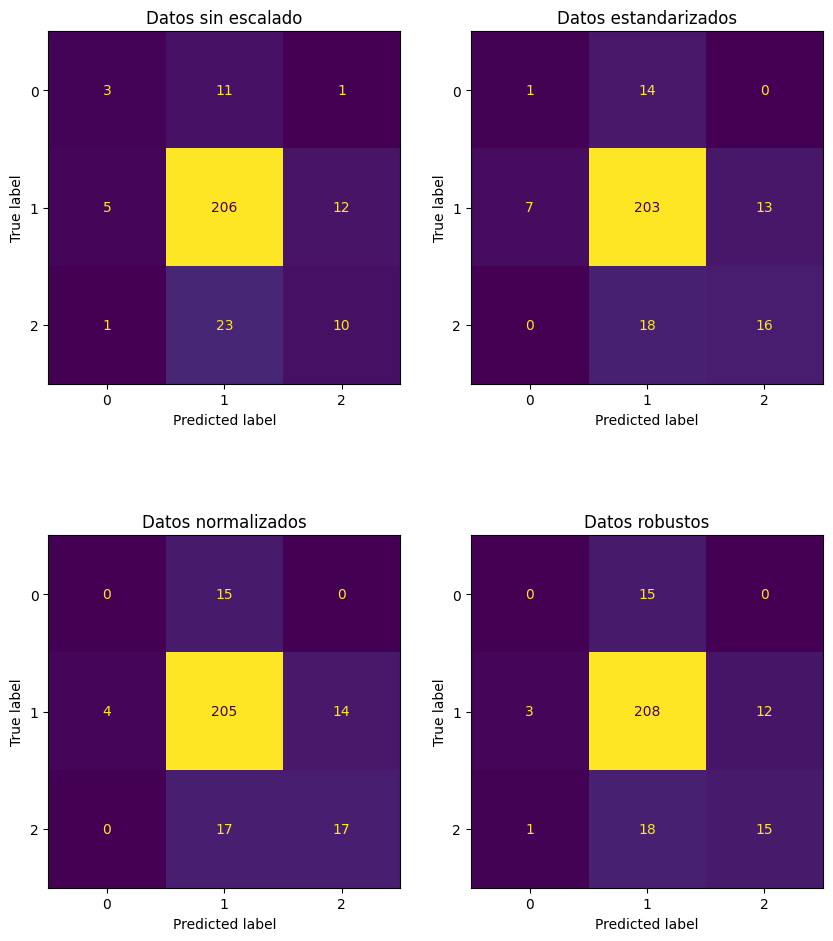

In [25]:
# Matriz de Confusión

## SIN ESCALADO
cm_no_scaling = confusion_matrix(Y_test, yhat_no_scaling)
## ESTANDARIZADO
cm_standard = confusion_matrix(Y_test, yhat_standard)
## NORMALIZADO
cm_norm = confusion_matrix(Y_test, yhat_norm)
## ROBUSTO
cm_robust = confusion_matrix(Y_test, yhat_robust)

#Gráfico

fig, axis=plt.subplots(2,2, figsize=(10,12))
ConfusionMatrixDisplay(confusion_matrix=cm_no_scaling).plot(ax=axis[0,0],cmap='viridis',colorbar=False)
axis[0,0].set_title("Datos sin escalado")
ConfusionMatrixDisplay(confusion_matrix=cm_standard).plot(ax=axis[0,1],cmap='viridis', colorbar=False)
axis[0,1].set_title("Datos estandarizados")
plt.plot()
ConfusionMatrixDisplay(confusion_matrix=cm_norm).plot(ax=axis[1,0],cmap='viridis', colorbar=False)
axis[1,0].set_title("Datos normalizados")
ConfusionMatrixDisplay(confusion_matrix=cm_robust).plot(ax=axis[1,1],cmap='viridis', colorbar=False)
axis[1,1].set_title("Datos robustos")

Recall = Cuántos identifica

Precision = Cuántos aciertos tiene en sus predicciones

Acuracy = Cuantos aciertos en total (la suma de la diagonal)/ total de muestras

# 7 BUCLE CON 20 VALORES DIFERENTES DE K (MÉTODO SIN ESCALAR, QUE ES EL MEJOR EN GENERAL)

In [26]:
# Lista para guardar los resultados
resultados = []

# Probar valores de k de 1 a 20
for k in range(1, 21):
    # Entrenar modelo KNN con k vecinos
    knn = KNeighborsClassifier(n_neighbors=k, algorithm='brute')
    knn.fit(X_train, Y_train)
    
    # Hacer predicciones
    y_pred = knn.predict(X_test)
    
    # Calcular accuracy
    acc = accuracy_score(Y_test, y_pred)
    
    # Guardar resultado
    resultados.append({
        'k': k,
        'accuracy': acc
    })
    
    print(f'K = {k:2d} → Accuracy = {acc:.4f}')

# Convertir a DataFrame para ver mejor
df_resultados = pd.DataFrame(resultados)

# Encontrar el mejor K
mejor_k = df_resultados.loc[df_resultados['accuracy'].idxmax(), 'k']
mejor_accuracy = df_resultados['accuracy'].max()



print(f"MEJOR K: {int(mejor_k)}")
print(f"MEJOR ACCURACY: {mejor_accuracy:.4f}")

K =  1 → Accuracy = 0.7610
K =  2 → Accuracy = 0.7757
K =  3 → Accuracy = 0.8051
K =  4 → Accuracy = 0.8456
K =  5 → Accuracy = 0.8346
K =  6 → Accuracy = 0.8199
K =  7 → Accuracy = 0.8272
K =  8 → Accuracy = 0.8272
K =  9 → Accuracy = 0.8125
K = 10 → Accuracy = 0.8199
K = 11 → Accuracy = 0.8235
K = 12 → Accuracy = 0.8235
K = 13 → Accuracy = 0.8346
K = 14 → Accuracy = 0.8272
K = 15 → Accuracy = 0.8235
K = 16 → Accuracy = 0.8235
K = 17 → Accuracy = 0.8235
K = 18 → Accuracy = 0.8235
K = 19 → Accuracy = 0.8235
K = 20 → Accuracy = 0.8199
MEJOR K: 4
MEJOR ACCURACY: 0.8456


## 7.1 GRÁFICA

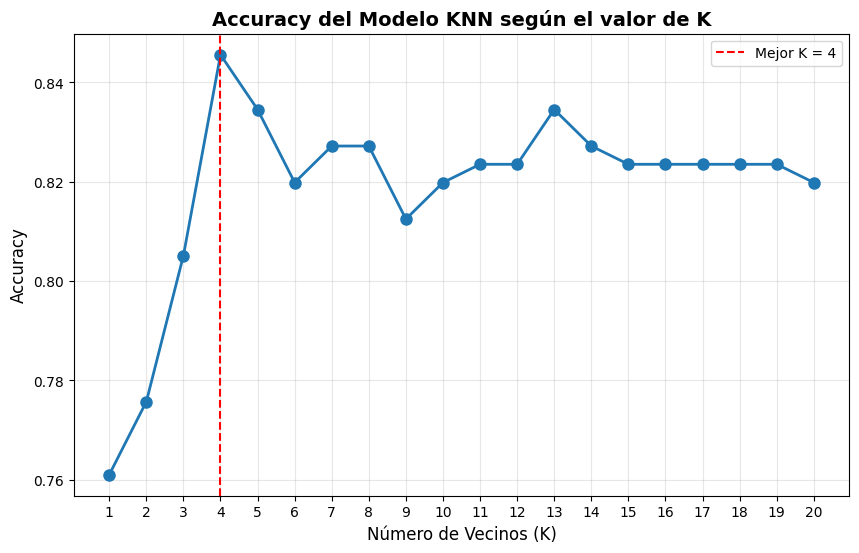

In [27]:
# Gráfico para ver cómo cambia el accuracy con diferentes K
plt.figure(figsize=(10, 6))
plt.plot(df_resultados['k'], df_resultados['accuracy'], marker='o', linewidth=2, markersize=8)
plt.xlabel('Número de Vecinos (K)', fontsize=12)
plt.ylabel('Accuracy', fontsize=12)
plt.title('Accuracy del Modelo KNN según el valor de K', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.xticks(range(1, 21))
plt.axvline(x=mejor_k, color='red', linestyle='--', label=f'Mejor K = {int(mejor_k)}')
plt.legend()
plt.show()

# 8 BUCLE CON 20 VALORES DIFERENTES DE K (MÉTODO CON ROBUSTSKALER, QUE ES MEJOR EN ACURACY)

In [28]:
# Aplicar RobustScaler a los datos
sc_robust_bucle = RobustScaler().fit(X_train)
X_train_robust = sc_robust_bucle.transform(X_train)
X_test_robust = sc_robust_bucle.transform(X_test)

# Lista para guardar los resultados
resultados_robust = []

# Probar valores de k de 1 a 20 con datos escalados con RobustScaler
for k in range(1, 21):
    # Entrenar modelo KNN con k vecinos usando datos escalados
    knn_robust = KNeighborsClassifier(n_neighbors=k, algorithm='brute')
    knn_robust.fit(X_train_robust, Y_train)
    
    # Hacer predicciones
    y_pred_robust = knn_robust.predict(X_test_robust)
    
    # Calcular accuracy
    acc_robust = accuracy_score(Y_test, y_pred_robust)
    
    # Guardar resultado
    resultados_robust.append({
        'k': k,
        'accuracy': acc_robust
    })
    
    print(f'K = {k:2d} → Accuracy = {acc_robust:.4f}')

# Convertir a DataFrame para ver mejor
df_resultados_robust = pd.DataFrame(resultados_robust)

# Encontrar el mejor K
mejor_k_robust = df_resultados_robust.loc[df_resultados_robust['accuracy'].idxmax(), 'k']
mejor_accuracy_robust = df_resultados_robust['accuracy'].max()


print(f"MEJOR K: {int(mejor_k_robust)}")
print(f"MEJOR ACCURACY: {mejor_accuracy_robust:.4f}")


K =  1 → Accuracy = 0.7757
K =  2 → Accuracy = 0.7978
K =  3 → Accuracy = 0.8199
K =  4 → Accuracy = 0.8235
K =  5 → Accuracy = 0.8162
K =  6 → Accuracy = 0.8235
K =  7 → Accuracy = 0.8456
K =  8 → Accuracy = 0.8493
K =  9 → Accuracy = 0.8529
K = 10 → Accuracy = 0.8493
K = 11 → Accuracy = 0.8382
K = 12 → Accuracy = 0.8529
K = 13 → Accuracy = 0.8419
K = 14 → Accuracy = 0.8529
K = 15 → Accuracy = 0.8493
K = 16 → Accuracy = 0.8493
K = 17 → Accuracy = 0.8456
K = 18 → Accuracy = 0.8382
K = 19 → Accuracy = 0.8382
K = 20 → Accuracy = 0.8419
MEJOR K: 9
MEJOR ACCURACY: 0.8529


## 8.1 GRÁFICA

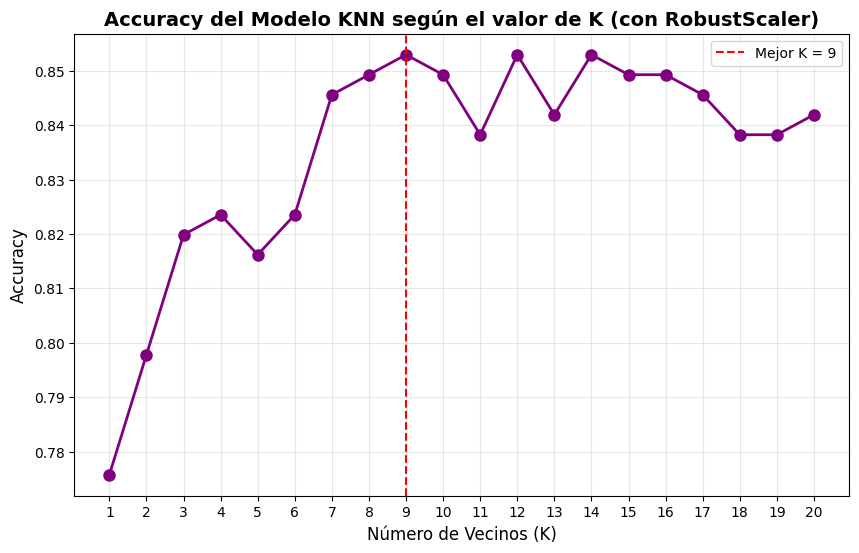

In [29]:
# Gráfico para ver cómo cambia el accuracy con diferentes K usando RobustScaler
plt.figure(figsize=(10, 6))
plt.plot(df_resultados_robust['k'], df_resultados_robust['accuracy'], marker='o', linewidth=2, markersize=8, color='purple')
plt.xlabel('Número de Vecinos (K)', fontsize=12)
plt.ylabel('Accuracy', fontsize=12)
plt.title('Accuracy del Modelo KNN según el valor de K (con RobustScaler)', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.xticks(range(1, 21))
plt.axvline(x=mejor_k_robust, color='red', linestyle='--', label=f'Mejor K = {int(mejor_k_robust)}')
plt.legend()
plt.show()

# 9 PRUEBA CON LOS NUEVOS K EN CADA MÉTODO 

In [30]:
# k-NN sin escalado de datos
yhat_no_scaling_nk = KNeighborsClassifier(n_neighbors=4, algorithm='brute').fit(X_train, Y_train).predict(X_test)

# k-NN con datos escalados usando RobustScaler
sc_robust_nk = RobustScaler().fit(X_train)
yhat_robust_nk = KNeighborsClassifier(n_neighbors=9, algorithm='brute').fit(sc_robust_nk.transform(X_train), Y_train).predict(sc_robust_nk.transform(X_test))

In [31]:
print(f'Reporte para los datos sin escalar:\n{classification_report(Y_test, yhat_no_scaling_nk)}')
print(f'Reporte para los datos normalizados con RobustScaler:\n{classification_report(Y_test, yhat_robust_nk)}')

Reporte para los datos sin escalar:
              precision    recall  f1-score   support

           0       1.00      0.07      0.12        15
           1       0.85      0.99      0.92       223
           2       0.73      0.24      0.36        34

    accuracy                           0.85       272
   macro avg       0.86      0.43      0.47       272
weighted avg       0.84      0.85      0.80       272

Reporte para los datos normalizados con RobustScaler:
              precision    recall  f1-score   support

           0       0.00      0.00      0.00        15
           1       0.87      0.96      0.91       223
           2       0.67      0.53      0.59        34

    accuracy                           0.85       272
   macro avg       0.51      0.50      0.50       272
weighted avg       0.80      0.85      0.82       272



c:\Users\ingen\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\ingen\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\ingen\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(ave

CONCLUSIÓN: 

CON LOS NUEVOS K EN AMBOS CASOS EFECTIVAMENTE EL ACURACY (PREDICCIONES CORRECTA) MEJORÓ.

EN EL ROBUSTSKALER MEJORA LA DETECCIÓN PARA LA CLASE 1 Y 2 PERO SIGUE SIENDO MUY MALO PARA DETECTAR LOS VINOS DE BAJA CALIDAD.

EL MÉTODO SIN ESCALAR EMPEORA LA DETECCIÓN DE LOS VINOS MALOS Y EXCELENTES Y MEJORA LA DETECCIÓN DE LOS VINOS DE CALIDAD MEDIA.

CREO QUE LA DECISIÓN FINAL DEPENDERÁ DE LAS NECESIDADES DEL CLIENTE

# 10 FUNCIÓN PARA PREDECIR LA CALIDAD DE UN VINO

In [32]:
def predecir_calidad_vino(fixed_acidity, volatile_acidity, citric_acid, residual_sugar, 
                          chlorides, free_sulfur_dioxide, total_sulfur_dioxide, density, 
                          pH, sulphates, alcohol, usar_escalado=False):
    """
    Predice la calidad de un vino basándose en sus características químicas.
    
    Parámetros:
    -----------
    fixed_acidity : float - Acidez fija 
    volatile_acidity : float - Acidez volátil 
    citric_acid : float - Ácido cítrico 
    residual_sugar : float - Azúcar residual 
    chlorides : float - Cloruros 
    free_sulfur_dioxide : float - Dióxido de azufre libre 
    total_sulfur_dioxide : float - Dióxido de azufre total 
    density : float - Densidad 
    pH : float - pH
    sulphates : float - Sulfatos 
    alcohol : float - Alcohol 
    usar_escalado : bool - Si True usa RobustScaler, si False usa sin escalar (por defecto False)
    
    Retorna:
    --------
    int : Calidad predicha (0=Baja, 1=Media, 2=Alta)
    """
    
    # Crear array con los valores de entrada
    vino_nuevo = np.array([[fixed_acidity, volatile_acidity, citric_acid, residual_sugar,
                           chlorides, free_sulfur_dioxide, total_sulfur_dioxide, density,
                           pH, sulphates, alcohol]])
    
    if usar_escalado:
        # Usar modelo con RobustScaler (K=9)
        vino_escalado = sc_robust_nk.transform(vino_nuevo)
        modelo = KNeighborsClassifier(n_neighbors=9, algorithm='brute').fit(
            sc_robust_nk.transform(X_train), Y_train)
        prediccion = modelo.predict(vino_escalado)[0]
        metodo_usado = "RobustScaler (K=9)"
    else:
        # Usar modelo sin escalar (K=4)
        modelo = KNeighborsClassifier(n_neighbors=4, algorithm='brute').fit(X_train, Y_train)
        prediccion = modelo.predict(vino_nuevo)[0]
        metodo_usado = "Sin Escalar (K=4)"
    
    # Interpretar resultado
    categorias = {
        0: "Baja Calidad (3-4)",
        1: "Calidad Media (5-6)",
        2: "Alta Calidad (7-8)"
    }
    
    print("="*60)
    print("PREDICCIÓN DE CALIDAD DEL VINO")
    print("="*60)
    print(f"Método usado: {metodo_usado}")
    print(f"Predicción numérica: {prediccion}")
    print(f"Categoría: {categorias[prediccion]}")
    print("="*60)
    
    return prediccion

## 10.1 EJEMPLO DE USO DE LA FUNCIÓN

In [33]:
# Ejemplo 1: Predicción SIN escalar (K=4)
# Usar los valores promedio del dataset
resultado1 = predecir_calidad_vino(
    fixed_acidity=8.32,
    volatile_acidity=0.53,
    citric_acid=0.27,
    residual_sugar=2.54,
    chlorides=0.09,
    free_sulfur_dioxide=15.87,
    total_sulfur_dioxide=46.47,
    density=0.997,
    pH=3.31,
    sulphates=0.66,
    alcohol=10.42,
    usar_escalado=False
)

print("\n")

# Ejemplo 2: Predicción CON RobustScaler (K=8)
resultado2 = predecir_calidad_vino(
    fixed_acidity=8.32,
    volatile_acidity=0.53,
    citric_acid=0.27,
    residual_sugar=2.54,
    chlorides=0.09,
    free_sulfur_dioxide=15.87,
    total_sulfur_dioxide=46.47,
    density=0.997,
    pH=3.31,
    sulphates=0.66,
    alcohol=10.42,
    usar_escalado=True
)

PREDICCIÓN DE CALIDAD DEL VINO
Método usado: Sin Escalar (K=4)
Predicción numérica: 1
Categoría: Calidad Media (5-6)


PREDICCIÓN DE CALIDAD DEL VINO
Método usado: RobustScaler (K=9)
Predicción numérica: 1
Categoría: Calidad Media (5-6)


c:\Users\ingen\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but KNeighborsClassifier was fitted with feature names
  warnings.warn(
c:\Users\ingen\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but RobustScaler was fitted with feature names
  warnings.warn(
